In [1]:
#1. Import data
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

train = pd.read_csv("../data/train.csv")
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
#2. Eda cơ bản
train.shape

(42000, 785)

In [3]:
print(train.columns[:10])
print(train.columns[-10:])

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8'],
      dtype='str')
Index(['pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str')


In [4]:
train.isnull().sum().sum()

np.int64(0)

In [5]:
#3. Tách label
train.columns
TARGET = "label"
x = train.drop(columns=[TARGET])
y = train[TARGET]
print("X shape", x.shape)
print("Y shape", y.shape)

print("\n Features: ")
print(x.columns.tolist())

print("\n Label: ")
print(y.head())

print(y.value_counts())
print(y.value_counts(normalize= True))


X shape (42000, 784)
Y shape (42000,)

 Features: 
['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel82', 'pixel83', 'pixel84', 'pixel85', 'pixel86', '

In [6]:
#4. Reshape
image = x.iloc[0].values #Lấy values của vị trí x số 0

print(image.shape)

(784,)


In [7]:
image = image.reshape(28, 28) #Chuyển thành shape 28 x 28

print(image.shape)

(28, 28)


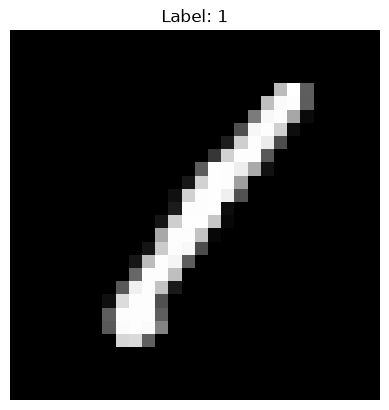

In [8]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray") #Tạo image với bảng màu xám (grayscale) bảng chỉ có màu xám - trắng - đen
plt.title(f"Label: {y.iloc[0]}") #Tạo title của ảnh vói y
plt.axis("off") #Ẩn trục tọa độ
plt.show() #Hiển thị

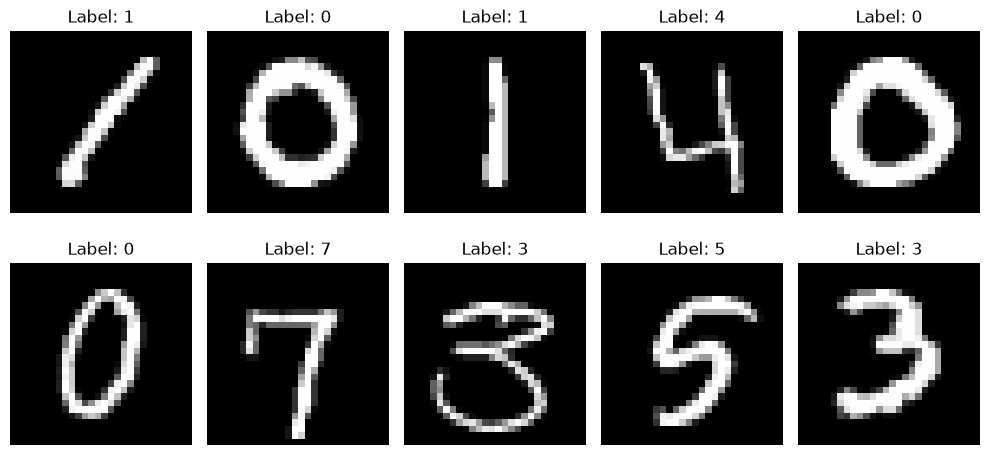

In [9]:
fig, axes = plt.subplots(2, 5, figsize = (10, 5)) 
#fig là gọi vùng vẽ lớn, axes là vùng vẽ nhỏ, subplots là tạo khung ảnh 2 hàng 5 cột. figsize là kích thước vùng vẽ 10 x 5 inch

for i, ax in enumerate(axes. flatten()):
#ax là lấy ô axes thứ... để vẽ
    image = x.iloc[i].values.reshape(28,28)

    ax.imshow(image, cmap = "gray")
    ax.set_title(f"Label: {y.iloc[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [10]:
#5. Chia Train / validation
x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2, #lấy 20% làm valid
    random_state=42, # Cố định tính ngẫu nhiên
    stratify=y
)


print("X_train:", x_train.shape)#Dữ liệu train model
print("X_val:", x_val.shape)#Dữ liệu validation aka kiểm tra
print("y_train:", y_train.shape)#Dữ liệu label y train tương ứng x train
print("y_val:", y_val.shape)

print("Train label distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation label distribution:")
print(y_val.value_counts().sort_index())

X_train: (33600, 784)
X_val: (8400, 784)
y_train: (33600,)
y_val: (8400,)
Train label distribution:
label
0    3305
1    3747
2    3342
3    3481
4    3258
5    3036
6    3310
7    3521
8    3250
9    3350
Name: count, dtype: int64

Validation label distribution:
label
0    827
1    937
2    835
3    870
4    814
5    759
6    827
7    880
8    813
9    838
Name: count, dtype: int64


In [11]:
#6. Normalize data
x_train = x_train/255.0
x_val = x_val/255.0
print("Min:", x_train.min().min())
print("Max:", x_train.max().max())

Min: 0.0
Max: 1.0


In [12]:
#7. Train baseline model - Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [13]:
#8. Tính train và valid accuracy
y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)

from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred) # Model dự đoán đúng bao nhiêu % trên dữ liệu train
val_accuracy = accuracy_score(y_val, y_val_pred) # của dữ liệu valid

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

accuracy_gap = train_accuracy - val_accuracy

print(f"Accuracy gap: {accuracy_gap:.4f}")

Train Accuracy: 0.9460
Validation Accuracy: 0.9127
Accuracy gap: 0.0332


In [14]:
#9. Simple / Complex model bằng C
model_simple = LogisticRegression(
    C= 0.01,
    max_iter=1000
)

model_simple.fit(x_train, y_train)

train_accuracy_simple = model_simple.score(x_train, y_train)
val_accuracy_simple = model_simple.score(x_val, y_val)

print(f"Train Accuracy: {train_accuracy_simple:.4f}")
print(f"Validation Accuracy: {val_accuracy_simple:.4f}")

model_complex = LogisticRegression(
    C= 100,
    max_iter=1000
)
model_complex.fit(x_train, y_train)

train_accuracy_complex = model_complex.score(x_train, y_train)
val_accuracy_complex = model_complex.score(x_val, y_val)

Train Accuracy: 0.9167
Validation Accuracy: 0.9086


In [15]:
#10. Results table
results = {
    "C": [0.01, 1, 100],
    "Train Accuracy": [
        train_accuracy_simple,
        train_accuracy,
        train_accuracy_complex
    ],
    "Validation Accuracy": [
        val_accuracy_simple,
        val_accuracy,
        val_accuracy_complex
    ]
}

results_df = pd.DataFrame(results)

results_df["Accuracy Gap"] = (
    results_df["Train Accuracy"]
    - results_df["Validation Accuracy"]
)

results_df

,C,Train Accuracy,Validation Accuracy,Accuracy Gap
0,0.01,0.916696,0.908571,0.008125
1,1.00,0.945952,0.912738,0.033214
2,100.00,0.954970,0.901786,0.053185


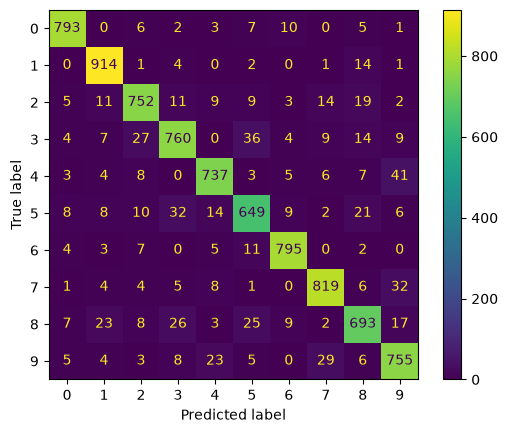

In [16]:
#11. Confusion matrix
best_model = model #chọn model accuracy cao nhất
y_val_pred = best_model.predict(x_val)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred) #Tính confusion matrix

disp = ConfusionMatrixDisplay( #Tạo display
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot()
plt.show()

In [17]:
cm_errors = cm.copy() #Tạo bản sao
np.fill_diagonal(cm_errors, 0) #Đặt đường chéo chính về 0 vì đường chéo chính là dự đoán đúng

true_digit, predicted_digit = np.unravel_index( #chuyển thành tọa độ trong ma trận vì np.argmax không trả về tọa độ
    np.argmax(cm_errors), #Trải phẳng ma trận
    cm_errors.shape #Kích thước ma trận MNIST: 10 x 10 -> Đưa ma trận trải phẳng về lại 10 x 10
)

print("Actual digit:", true_digit)
print("Predicted as:", predicted_digit)
print("Number of mistakes:",
      cm_errors[true_digit, predicted_digit])

Actual digit: 4
Predicted as: 9
Number of mistakes: 41


In [18]:
wrong_indices = np.where(
    y_val_pred != y_val.to_numpy()
)[0]

print("Number of wrong predictions:",
      len(wrong_indices))

Number of wrong predictions: 733


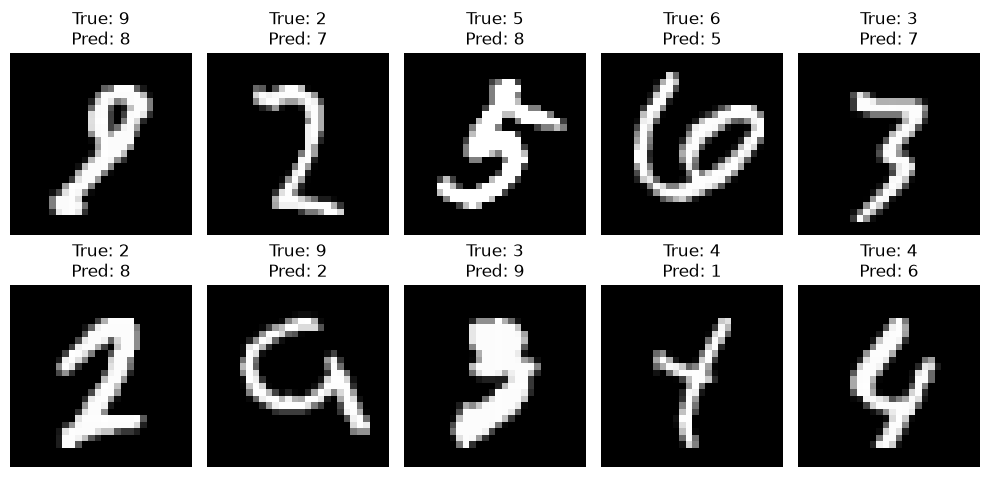

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, idx in zip(axes.ravel(), wrong_indices[:10]):
    image = x_val.iloc[idx].to_numpy().reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"True: {y_val.iloc[idx]}\nPred: {y_val_pred[idx]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
### Nhận xét

# - Logistic Regression dự đoán sai 733 mẫu trong validation set.
# - Cặp chữ số bị nhầm nhiều nhất là số 4 thành số 9, với 41 trường hợp.
# - Một số cặp khác cũng thường bị nhầm như 3 → 5, 7 → 9 và 5 → 3.
# - Khi quan sát trực tiếp các ảnh dự đoán sai, nhiều chữ số có nét viết méo,
#   không rõ hoặc có hình dạng gần giống một chữ số khác.
# - Các lỗi này cũng cho thấy giới hạn của Logistic Regression khi biểu diễn
#   các pattern hình ảnh phức tạp.